In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import sys
sys.path.append("../")

from transformer_lens import HookedTransformer
from src.data.activation_extractor import extract_residual_stream, get_token_position

model = HookedTransformer.from_pretrained("gpt2")
model.eval()

/home/baskar/Desktop/mi-probe-suite/venv/lib/python3.12/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2 into HookedTransformer


HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint(name='hook_embed')
  (pos_embed): PosEmbed()
  (hook_pos_embed): HookPoint(name='hook_pos_embed')
  (blocks): ModuleList(
    (0): TransformerBlock(
      (ln1): LayerNormPre(
        (hook_scale): HookPoint(name='blocks.0.ln1.hook_scale')
        (hook_normalized): HookPoint(name='blocks.0.ln1.hook_normalized')
      )
      (ln2): LayerNormPre(
        (hook_scale): HookPoint(name='blocks.0.ln2.hook_scale')
        (hook_normalized): HookPoint(name='blocks.0.ln2.hook_normalized')
      )
      (attn): Attention(
        (hook_k): HookPoint(name='blocks.0.attn.hook_k')
        (hook_q): HookPoint(name='blocks.0.attn.hook_q')
        (hook_v): HookPoint(name='blocks.0.attn.hook_v')
        (hook_z): HookPoint(name='blocks.0.attn.hook_z')
        (hook_attn_scores): HookPoint(name='blocks.0.attn.hook_attn_scores')
        (hook_pattern): HookPoint(name='blocks.0.attn.hook_pattern')
        (hook_result): HookPoint(name='blo

In [2]:
prompts_and_subjects = [
    ("The capital of France is", "France"),
    ("The capital of Germany is", "Germany"),
    ("The capital of Japan is", "Japan"),
    ("The capital of Italy is", "Italy"),
]

for prompt, country in prompts_and_subjects:
    str_tokens = model.to_str_tokens(prompt)
    pos = get_token_position(model, prompt, country)
    print(f"Prompt : {prompt!r}")
    print(f"Tokens : {str_tokens}")
    print(f"Country: '{country}' at position {pos}")
    print()

Prompt : 'The capital of France is'
Tokens : ['<|endoftext|>', 'The', ' capital', ' of', ' France', ' is']
Country: 'France' at position 4

Prompt : 'The capital of Germany is'
Tokens : ['<|endoftext|>', 'The', ' capital', ' of', ' Germany', ' is']
Country: 'Germany' at position 4

Prompt : 'The capital of Japan is'
Tokens : ['<|endoftext|>', 'The', ' capital', ' of', ' Japan', ' is']
Country: 'Japan' at position 4

Prompt : 'The capital of Italy is'
Tokens : ['<|endoftext|>', 'The', ' capital', ' of', ' Italy', ' is']
Country: 'Italy' at position 4



Tokens: ['<|endoftext|>', 'The', ' capital', ' of', ' France', ' is', ' Paris']


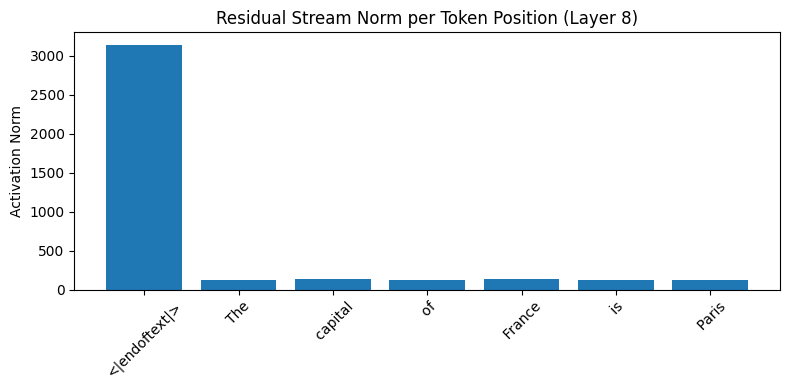

In [3]:
prompt = "The capital of France is Paris"
tokens = model.to_str_tokens(prompt)
print("Tokens:", tokens)

with torch.no_grad():
    _, cache = model.run_with_cache(prompt)

layer = 8
resid = cache[f"blocks.{layer}.hook_resid_post"]
all_positions = resid[0, :, :].detach().numpy()  # (n_tokens, 768)
norms = np.linalg.norm(all_positions, axis=1)

plt.figure(figsize=(8, 4))
plt.bar(range(len(tokens)), norms)
plt.xticks(range(len(tokens)), tokens, rotation=45)
plt.ylabel("Activation Norm")
plt.title(f"Residual Stream Norm per Token Position (Layer {layer})")
plt.tight_layout()
plt.savefig("../results/session4_token_position_norms.png")
plt.show()

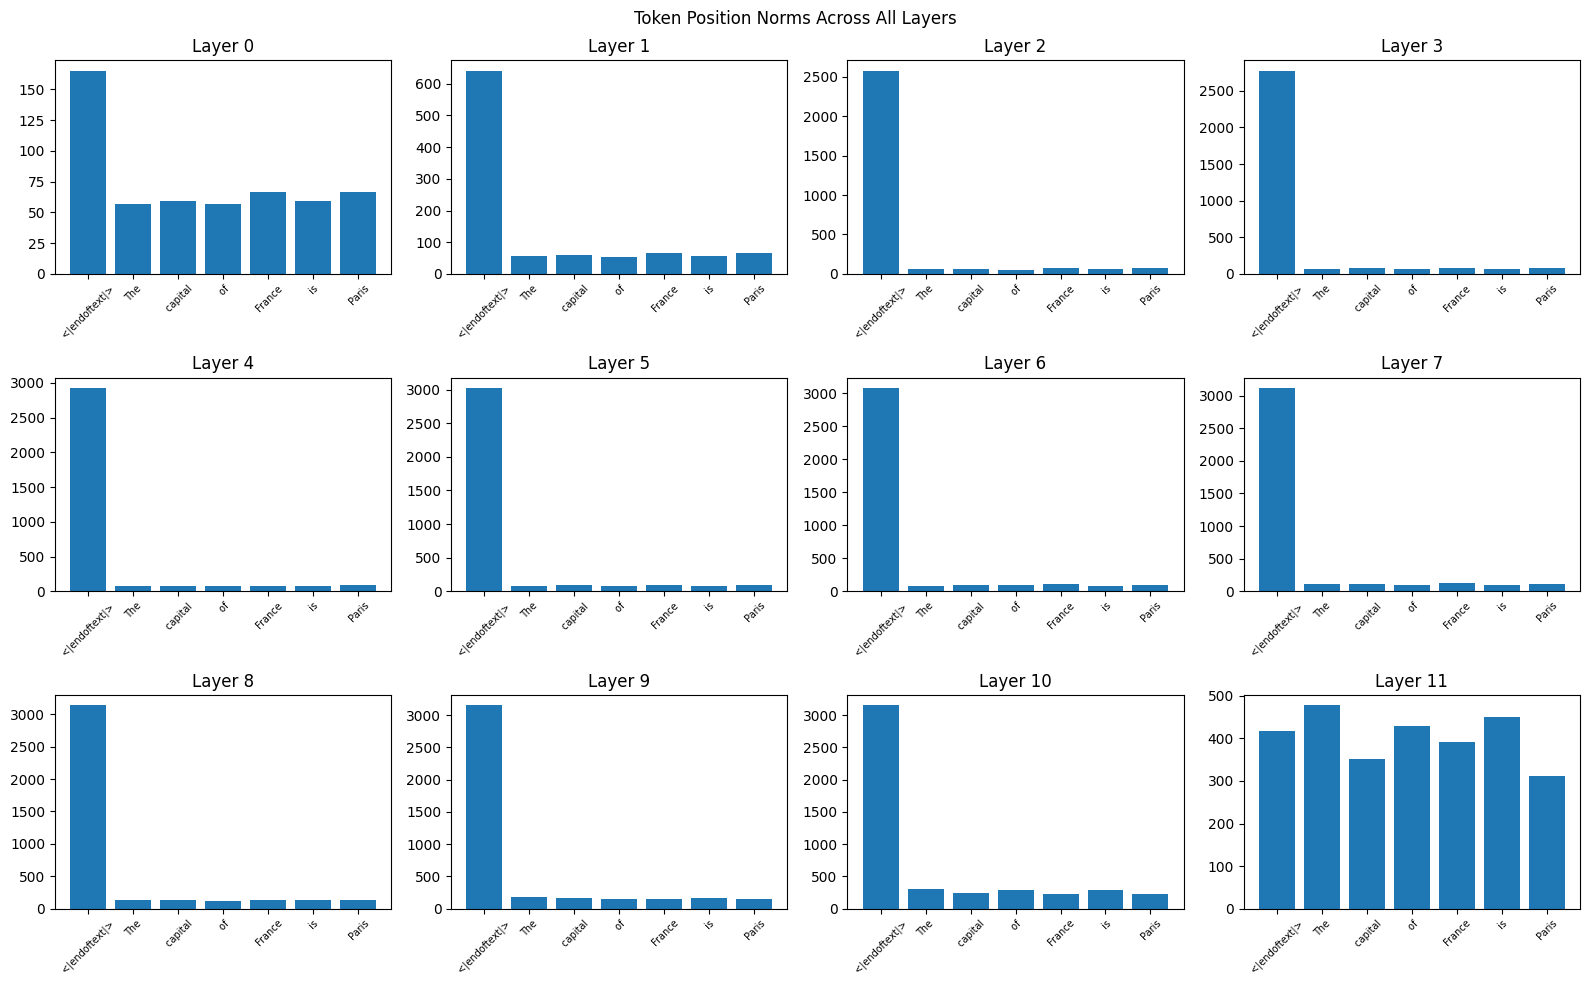

In [4]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for layer in range(model.cfg.n_layers):
    resid = cache[f"blocks.{layer}.hook_resid_post"]
    norms = resid[0, :, :].norm(dim=-1).detach().numpy()
    
    axes[layer].bar(range(len(tokens)), norms)
    axes[layer].set_xticks(range(len(tokens)))
    axes[layer].set_xticklabels(tokens, rotation=45, fontsize=7)
    axes[layer].set_title(f"Layer {layer}")

plt.suptitle("Token Position Norms Across All Layers")
plt.tight_layout()
plt.savefig("../results/session4_all_layers_token_norms.png")
plt.show()

In [5]:
layer = 8

last_token_acts = []
subject_token_acts = []

for prompt, country in prompts_and_subjects:
    # Always dynamically find position
    subject_pos = get_token_position(model, prompt, country)
    
    with torch.no_grad():
        _, cache = model.run_with_cache(prompt)
    
    resid = cache[f"blocks.{layer}.hook_resid_post"]
    
    last_token_acts.append(resid[0, -1, :].detach().numpy())
    subject_token_acts.append(resid[0, subject_pos, :].detach().numpy())

last_token_acts = np.array(last_token_acts)      # (4, 768)
subject_token_acts = np.array(subject_token_acts) # (4, 768)

print("Last token shape:", last_token_acts.shape)
print("Subject token shape:", subject_token_acts.shape)

Last token shape: (4, 768)
Subject token shape: (4, 768)


In [6]:
print("Subject token cosine similarity:")
print(np.round(cosine_similarity(subject_token_acts), 4))

print("\nLast token cosine similarity:")
print(np.round(cosine_similarity(last_token_acts), 4))

Subject token cosine similarity:
[[1.     0.9174 0.8823 0.9142]
 [0.9174 1.     0.9131 0.9232]
 [0.8823 0.9131 1.     0.9028]
 [0.9142 0.9232 0.9028 1.    ]]

Last token cosine similarity:
[[1.     0.998  0.9937 0.9972]
 [0.998  1.     0.9953 0.9972]
 [0.9937 0.9953 1.     0.9945]
 [0.9972 0.9972 0.9945 1.    ]]


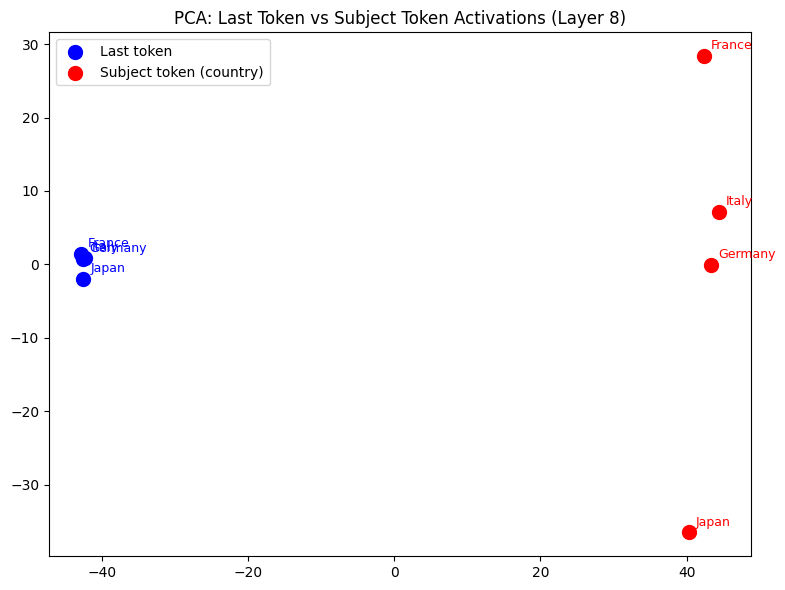

In [7]:
pca = PCA(n_components=2)
combined = np.vstack([last_token_acts, subject_token_acts])
reduced = pca.fit_transform(combined)

last_reduced = reduced[:4]
subject_reduced = reduced[4:]

countries = ["France", "Germany", "Japan", "Italy"]

plt.figure(figsize=(8, 6))
plt.scatter(last_reduced[:, 0], last_reduced[:, 1],
            c='blue', label='Last token', s=100)
plt.scatter(subject_reduced[:, 0], subject_reduced[:, 1],
            c='red', label='Subject token (country)', s=100)

for i, country in enumerate(countries):
    plt.annotate(country, last_reduced[i],
                fontsize=9, color='blue',
                xytext=(5, 5), textcoords='offset points')
    plt.annotate(country, subject_reduced[i],
                fontsize=9, color='red',
                xytext=(5, 5), textcoords='offset points')

plt.legend()
plt.title("PCA: Last Token vs Subject Token Activations (Layer 8)")
plt.tight_layout()
plt.savefig("../results/session4_pca_token_positions.png")
plt.show()

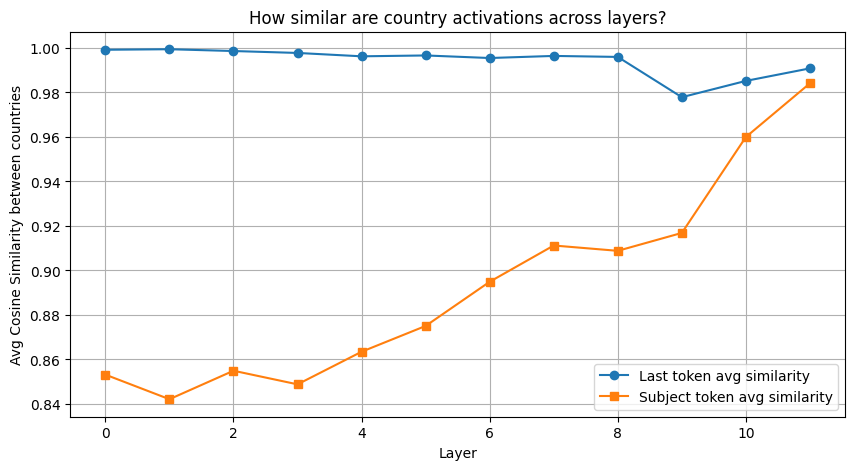

In [8]:
# Does the pattern change at different layers?
similarities_last = []
similarities_subject = []

for layer in range(model.cfg.n_layers):
    last_acts = []
    subj_acts = []
    
    for prompt, country in prompts_and_subjects:
        subject_pos = get_token_position(model, prompt, country)
        
        with torch.no_grad():
            _, cache = model.run_with_cache(prompt)
        
        resid = cache[f"blocks.{layer}.hook_resid_post"]
        last_acts.append(resid[0, -1, :].detach().numpy())
        subj_acts.append(resid[0, subject_pos, :].detach().numpy())
    
    last_acts = np.array(last_acts)
    subj_acts = np.array(subj_acts)
    
    # Average pairwise similarity (excluding diagonal)
    last_sim = cosine_similarity(last_acts)
    subj_sim = cosine_similarity(subj_acts)
    
    avg_last = (last_sim.sum() - 4) / 12   # subtract diagonal
    avg_subj = (subj_sim.sum() - 4) / 12
    
    similarities_last.append(avg_last)
    similarities_subject.append(avg_subj)

plt.figure(figsize=(10, 5))
plt.plot(similarities_last, marker='o', label='Last token avg similarity')
plt.plot(similarities_subject, marker='s', label='Subject token avg similarity')
plt.xlabel("Layer")
plt.ylabel("Avg Cosine Similarity between countries")
plt.title("How similar are country activations across layers?")
plt.legend()
plt.grid(True)
plt.savefig("../results/session4_similarity_across_layers.png")
plt.show()

In [9]:
from src.data.activation_extractor import (
    get_token_position,
    extract_at_position,
    extract_all_positions
)

prompt = "The capital of France is"
pos = get_token_position(model, prompt, "France")
print(f"'France' is at position: {pos}")  # Should be 4, not 3

'France' is at position: 4


In [10]:
all_pos = extract_all_positions(model, prompt, layer=8)
print("All positions shape:", all_pos.shape)  # (n_tokens, 768)

All positions shape: (6, 768)


In [11]:
try:
    get_token_position(model, prompt, "Berlin")
except ValueError as e:
    print("Correctly raised ValueError:", e)

print("All tests passed ✅")

Correctly raised ValueError: Target 'Berlin' not found in tokens: ['<|endoftext|>', 'The', ' capital', ' of', ' France', ' is']
All tests passed ✅


In [14]:
sys.path.append("../")
from src.data.activation_extractor import get_token_position

prompts_and_subjects = [
    ("The capital of France is", "France"),
    ("The capital of Germany is", "Germany"),
    ("The capital of Japan is", "Japan"),
    ("The capital of Italy is", "Italy"),
]

# Dynamically find subject position
for prompt, country in prompts_and_subjects:
    pos = get_token_position(model, prompt, country)
    print(f"'{country}' found at position: {pos}")

ImportError: cannot import name 'get_token_position' from 'src.data.activation_extractor' (/home/baskar/Desktop/mi-probe-suite/notebooks/../src/data/activation_extractor.py)